<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/3-mfcc-speech-recognition-bases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ¿Por qué utilizar MFCC y la Transformada Discreta de Coseno (DCT)?

Dado que estamos utilizando el conjunto de datos RAVDESS, parte de nuestro objetivo final es diferenciar la emoción con la que se ha pronunciado una frase mediante técnicas de Deep Learning y Machine Learning. Esto nos permitirá obtener una serie de resultados para comparar ambos métodos, contrastando su precisión, costo computacional y rendimiento.

Pero, ¿por qué es fundamental centrarse en los MFCC (Mel-Frequency Cepstral Coefficients)?

La respuesta reside en que la información que poseen los coeficientes cepstrales es capaz de separar el sonido de su fuente. Por ejemplo, en el caso de una nota tocada por dos instrumentos distintos, los componentes de frecuencia (armónicos) pueden resultar muy similares, pero su intensidad no lo será del todo. Esto se debe a que la fuente posee características físicas únicas que filtran el sonido y definen el timbre que finalmente llega a nuestros oídos. Al aislarnos en el "filtro", obtenemos una descripción pura del **timbre**, independientemente de la nota que se esté ejecutando.

### ¿Por qué se utiliza la DCT?
Este es el paso final para obtener los MFCC y se realiza por dos razones técnicas fundamentales:

* A. **Decorrelación** (Limpieza de datos)
En un espectrograma de Mel, las bandas de frecuencia están estrechamente relacionadas entre sí (si la banda de 500 Hz es intensa, la de 510 Hz probablemente también lo sea). Esta redundancia es ineficiente. La DCT toma esa información "solapada" y la convierte en coeficientes independientes o decorrelacionados. Para un modelo de clasificación, es mucho más sencillo procesar 13 o 20 coeficientes independientes que una matriz densa con datos redundantes.

* B. **Compresión de "Forma"**
Los **primeros coeficientes** de la DCT representan las variaciones lentas y generales del espectro (la envolvente del timbre).

  Los **coeficientes altos** representan variaciones rápidas (detalles finos o ruido).

  Al aplicar la DCT, podemos descartar los coeficientes más altos y conservar solo los primeros (generalmente entre 12 y 20), los cuales contienen toda la información relevante para caracterizar el timbre emocional.



  ![Texto alternativo](https://github.com/AcSsalazar/the-color-of-emotions/blob/main/Color-online-The-MFCC-feature-extraction-process.jpg?raw=1)

In [2]:
import librosa
import matplotlib.pyplot as plt
import os
import numpy as np
import IPython.display as ipd

Para este notebook, vamos a emplear dos clips de audio diferentes a los usados anteriormente; esto con el fin de facilitar su distinción a simple escucha y la comprensión de las diferencias entre sus características. A continuación, podrás reproducir dichos clips y constatar que las emociones contrastan fuertemente.

In [3]:

import sys

# Detectamos si estamos ejecutando el código en Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')


    BASE_DIR = "/content/drive/MyDrive/Actor_01"

else:

    BASE_DIR = "./Actor_01"

# A partir de aquí, cargamos el archivo en ambos entornos de la misma manera
angry_clip = os.path.join(BASE_DIR, "Angry.wav")
calm_clip = os.path.join(BASE_DIR, "Calm.wav")

print(f"Cargando archivos desde: {BASE_DIR}")




Mounted at /content/drive
Cargando archivos desde: /content/drive/MyDrive/Actor_01


In [4]:
ipd.Audio(angry_clip)

In [5]:
ipd.Audio(calm_clip)

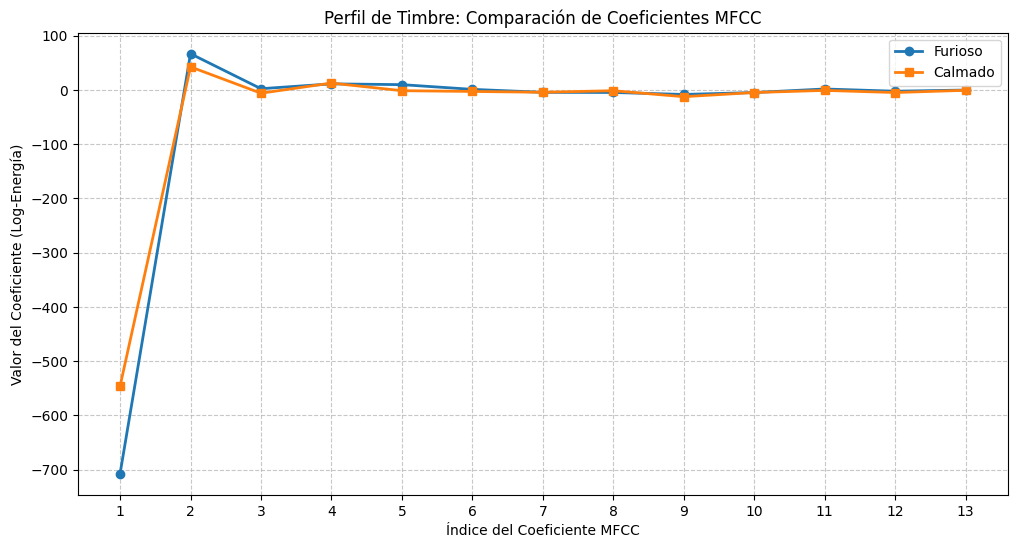

In [6]:

def comparar_mfcc(file_1, file_2, label_1="Furioso", label_2="Calmado"):
    # 1. Cargar audios (mismo sr para comparar peras con peras)
    y1, sr = librosa.load(file_1)
    y2, sr = librosa.load(file_2)

    # 2. Extraer MFCC (por defecto saca 20, nos quedamos con 13)
    mfcc1 = librosa.feature.mfcc(y=y1, sr=sr, n_mfcc=13)
    mfcc2 = librosa.feature.mfcc(y=y2, sr=sr, n_mfcc=13)

    # 3. Promediar en el tiempo para tener un "perfil" único del instrumento
    # (El MFCC devuelve una matriz de 13 x Frames, promediamos los frames)
    mfcc1_avg = np.mean(mfcc1, axis=1)
    mfcc2_avg = np.mean(mfcc2, axis=1)



    # 4. Graficar la comparación
    plt.figure(figsize=(12, 6))

    x = np.arange(1, 14) # Eje para los 13 coeficientes

    plt.plot(x, mfcc1_avg, label=label_1, marker='o', linewidth=2)
    plt.plot(x, mfcc2_avg, label=label_2, marker='s', linewidth=2)

    plt.title('Perfil de Timbre: Comparación de Coeficientes MFCC')
    plt.xlabel('Índice del Coeficiente MFCC')
    plt.ylabel('Valor del Coeficiente (Log-Energía)')
    plt.xticks(x)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


comparar_mfcc(calm_clip, angry_clip)

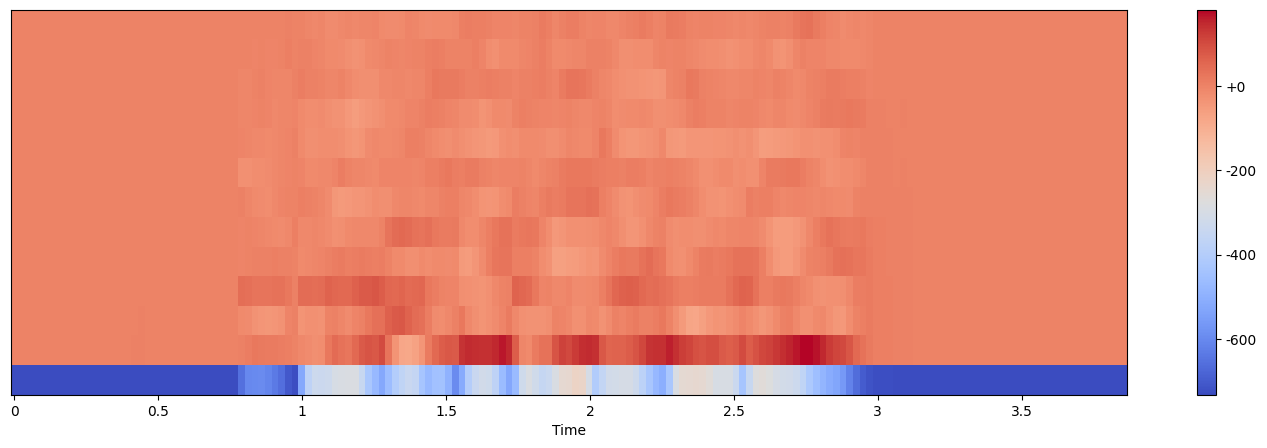

In [7]:
y1, sr = librosa.load(angry_clip)
y2, sr = librosa.load(calm_clip)


mfcc1 = librosa.feature.mfcc(y=y1, sr=sr, n_mfcc=13)
mfcc2 = librosa.feature.mfcc(y=y2, sr=sr, n_mfcc=13)


plt.figure(figsize=(18, 5))
librosa.display.specshow(mfcc1,
                         x_axis="time",
                         sr=sr)
plt.colorbar(format="%+2.f")
plt.show()

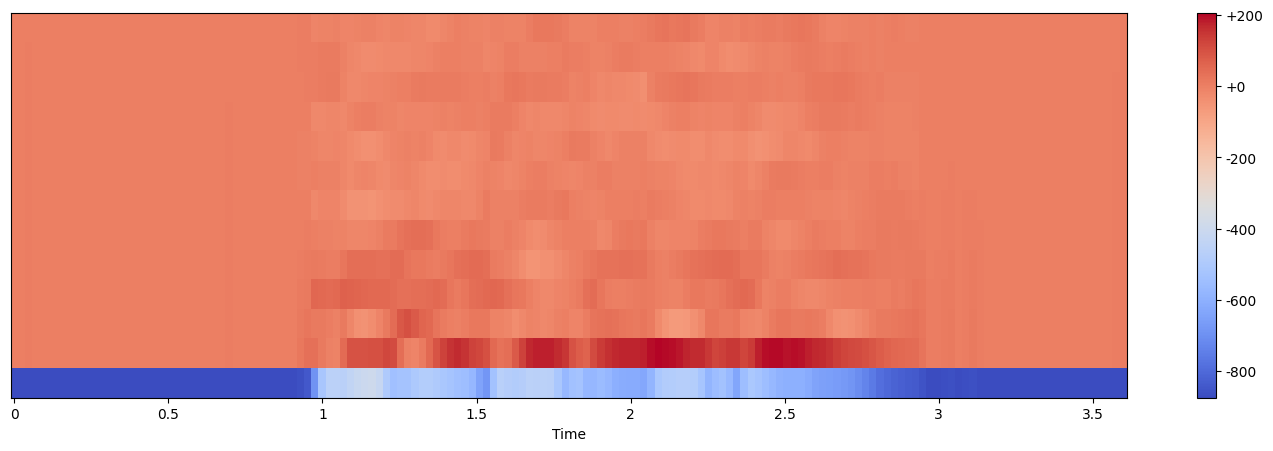

In [9]:
plt.figure(figsize=(18, 5))
librosa.display.specshow(mfcc2,
                         x_axis="time",
                         sr=sr)
plt.colorbar(format="%+2.f")
plt.show()

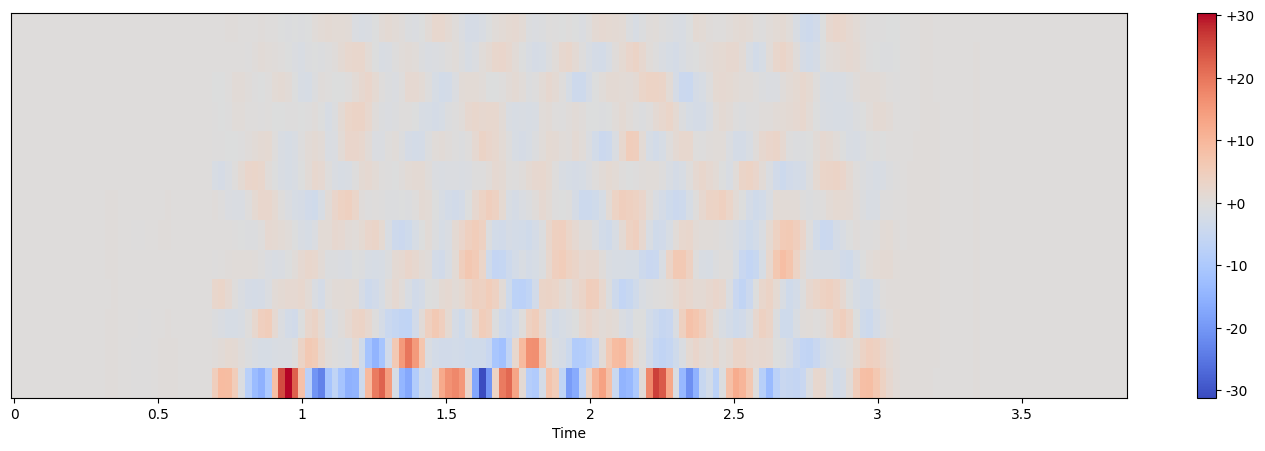

In [10]:
delta_021 = librosa.feature.delta(mfcc1, order=2)
delta_022 = librosa.feature.delta(mfcc2, order=2)

plt.figure(figsize=(18, 5))
librosa.display.specshow(delta_021,
                         x_axis="time",
                         sr=sr)
plt.colorbar(format="%+2.f")
plt.show()

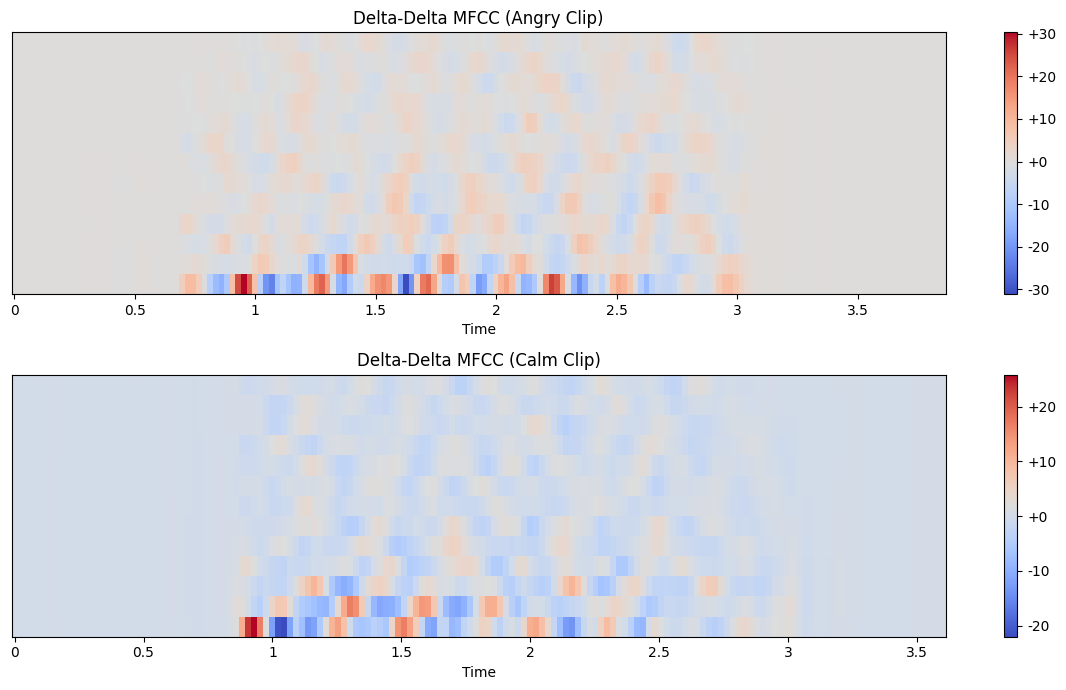

In [16]:
plt.figure(figsize=(12, 7))

def plot_delta(delta_array, sr, title, subplot_pos):
    plt.subplot(subplot_pos[0], subplot_pos[1], subplot_pos[2])
    librosa.display.specshow(delta_array,
                             x_axis="time",
                             sr=sr)
    plt.colorbar(format="%+2.f")
    plt.title(title)

plot_delta(delta_021, sr, 'Delta-Delta MFCC (Angry Clip)', (2, 1, 1)) # 2 rows, 1 column, 1st plot
plot_delta(delta_022, sr, 'Delta-Delta MFCC (Calm Clip)', (2, 1, 2))  # 2 rows, 1 column, 2nd plot

plt.tight_layout()
plt.show()

## El Delta-Delta

Para entender el Delta y el Delta-Delta (segundo orden), debemos dejar de ver los MFCC como una foto estática y empezar a verlos como un video.

Si los MFCC son la "posición" de la envolvente espectral en un instante, los deltas son su movimiento.

<br>

**1.El Concepto de Derivada**

* En física, si tienes la posición, la primera derivada es la velocidad y la segunda es la aceleración. En el audio funciona exactamente igual:

* MFCC Estáticos: Representan el "qué" se está diciendo (el timbre en un milisegundo exacto).

* **Delta (1er orden)**: Representa la velocidad de cambio de los coeficientes. Nos dice qué tan rápido está pasando el tracto vocal de una forma a otra (por ejemplo, al pasar de la letra "S" a la "O").


* **Delta-Delta (2do orden)**: Representa la aceleración. Nos dice si ese cambio de sonido se está frenando o acelerando.

<br>

**2.¿Por qué el 2do orden es vital para las emociones?**

Imaginemos que alguien está enojado frente a alguien que está triste:

* En el enojo: Los movimientos de la boca son bruscos y rápidos. Los coeficientes MFCC cambian de forma violenta. Aquí, el Delta-Delta tendrá valores muy altos (mucha aceleración/frenado brusco en el timbre).

* En la tristeza: Los cambios son lentos y arrastrados. Las transiciones entre sonidos son suaves. El Delta-Delta será muy bajo o cercano a cero, porque no hay "arranques" súbitos en la voz.





Sin el segundo orden, el modelo de Machine Learning solo vería "fotos" del timbre, pero perdería la dinámica del habla, que es donde realmente vive la emoción.